In [2]:
print("Quant AI Lab Starterd")

Quant AI Lab Starterd


In [4]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 4.4 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=09fa9c0f6311e932f5f4feb91e0fad17993178002e959e1593a3b0323c6e9d29
  Stored in directory: c:\users\aadhy\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ----------

In [5]:
import yfinance as yf

data = yf.download("AAPL",
                   start="2020-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


NameError: name 'plt' is not defined

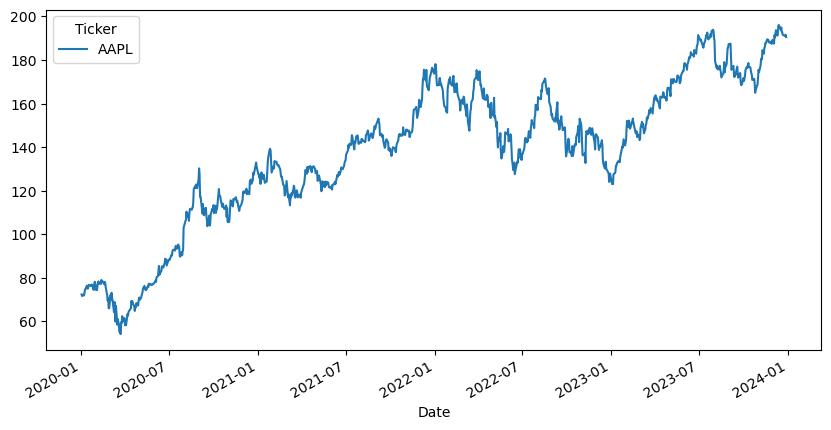

In [8]:
data["Close"].plot(figsize=(10,5))
plt.title("AAPL Price")
plt.show() 

In [10]:
data["Return"] = data["Close"].pct_change()

data["MA20"] = data["Close"].rolling(20).mean()

data["MA50"] = data["Close"].rolling(50).mean()

data.tail()

Price,Close,High,Low,Open,Volume,Return,MA20,MA50
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2023-12-22,191.609482,193.400870,190.985954,193.173224,37149600,-0.005547,191.677264,183.401252
2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300,-0.002841,191.838587,183.686989
2023-12-27,191.164078,191.510485,189.125261,190.510875,48087700,0.000518,191.974673,183.977276
2023-12-28,191.589661,192.658558,191.183873,192.143900,34049900,0.002226,192.183008,184.307111
2023-12-29,190.550446,192.401214,189.758668,191.906355,42672100,-0.005424,192.310679,184.642058


In [11]:
data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int)

data = data.dropna()

data.tail()

Price,Close,High,Low,Open,Volume,Return,MA20,MA50,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2023-12-22,191.609482,193.400870,190.985954,193.173224,37149600,-0.005547,191.677264,183.401252,0
2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300,-0.002841,191.838587,183.686989,1
2023-12-27,191.164078,191.510485,189.125261,190.510875,48087700,0.000518,191.974673,183.977276,1
2023-12-28,191.589661,192.658558,191.183873,192.143900,34049900,0.002226,192.183008,184.307111,0
2023-12-29,190.550446,192.401214,189.758668,191.906355,42672100,-0.005424,192.310679,184.642058,0


In [12]:
features = ["Return", "MA20", "MA50"]

X = data[features]
y = data["Target"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.4583333333333333


In [16]:
!pip install ta

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29497 sha256=dd46c6f91f304796a7ff59a0b85fb560385843fc4b2bd76b2bfce89afee5bde6
  Stored in directory: c:\users\aadhy\appdata\local\pip\cache\wheels\e3\3a\ee\4955a26c90a4b7deb6d725dc8ec7b8604a7aef44e43a2e8af7
Successfully built ta


In [18]:
data["Prediction"] = model.predict(X)

data[["Close","Prediction"]].tail()

Price,Close,Prediction
Ticker,AAPL,
Date,,
2023-12-22,191.609482,0
2023-12-26,191.065125,0
2023-12-27,191.164078,0
2023-12-28,191.589661,0
2023-12-29,190.550446,0


In [19]:
data["Strategy_Return"] = data["Prediction"].shift(1) * data["Return"]

data[["Return","Strategy_Return"]].head()

Price,Return,Strategy_Return
Ticker,,
Date,,
2020-03-13,0.119808,NaN
2020-03-16,-0.128647,-0.00000
2020-03-17,0.043970,0.04397
2020-03-18,-0.024480,-0.00000
2020-03-19,-0.007662,-0.00000


NameError: name 'plt' is not defined

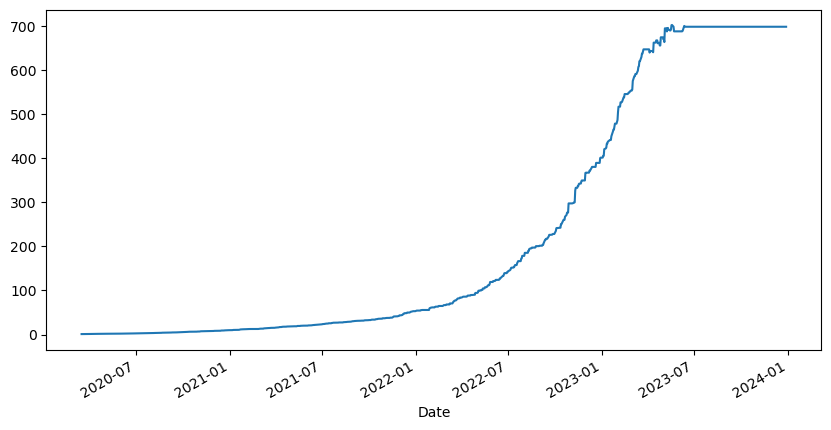

In [20]:
(data["Strategy_Return"] + 1).cumprod().plot(figsize=(10,5))
plt.title("AI Trading Strategy Performance")
plt.show()

In [21]:
import matplotlib.pyplot as plt

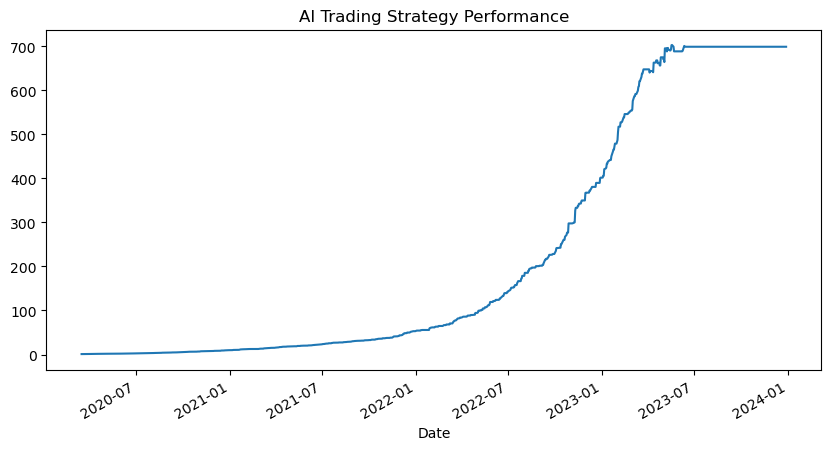

In [22]:
(data["Strategy_Return"] + 1).cumprod().plot(figsize=(10,5))
plt.title("AI Trading Strategy Performance")
plt.show()
